# Scenario 1 – Bagging
**Roll Number:** 24BAD002  
**Name:** Abhishek J

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print(f"Roll Number: 24BAD002")
print(f"Name: Abhishek J")

Roll Number: 24BAD002
Name: Abhishek J


## 1. Load Dataset

In [2]:
df = pd.read_csv("diabetes_bagging.csv")
print("Shape:", df.shape)
print(df.head())
print("\nClass Distribution:")
print(df['Outcome'].value_counts())


Shape: (120, 6)
   Glucose   BMI  Age  BloodPressure  Insulin  Outcome
0      182  21.1   45             99      100        1
1      131  35.6   67             92      199        1
2      172  19.6   68             68      234        1
3       94  39.7   21            102       83        0
4      186  35.0   20            113       61        1

Class Distribution:
Outcome
1    74
0    46
Name: count, dtype: int64


## 2. Prepare Features

In [3]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 96, Test size: 24


## 3. Train Decision Tree (Baseline)

In [4]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
print(f"Decision Tree Accuracy: {dt_acc:.4f}")


Decision Tree Accuracy: 0.9583


## 4. Apply BaggingClassifier

In [5]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    max_samples=0.8,
    max_features=0.8,
    random_state=42
)
bag.fit(X_train, y_train)
bag_pred = bag.predict(X_test)
bag_acc = accuracy_score(y_test, bag_pred)
print(f"Bagging Classifier Accuracy: {bag_acc:.4f}")


Bagging Classifier Accuracy: 1.0000


## 5. Visualization – Accuracy Comparison

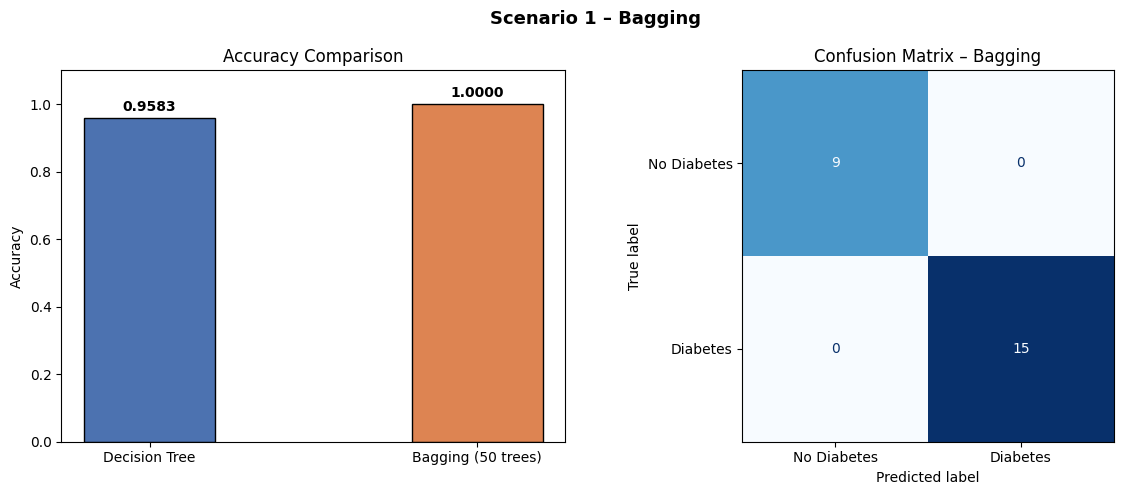

Plot saved.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"Scenario 1 – Bagging", fontsize=13, fontweight='bold')

# Bar chart
models = ['Decision Tree', 'Bagging (50 trees)']
accs = [dt_acc, bag_acc]
bars = axes[0].bar(models, accs, color=['#4C72B0', '#DD8452'], edgecolor='black', width=0.4)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy Comparison")
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{acc:.4f}", ha='center', fontweight='bold')

# Confusion matrix for Bagging
cm = confusion_matrix(y_test, bag_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title("Confusion Matrix – Bagging")

plt.tight_layout()
plt.savefig("scenario1_output.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")


## Summary

In [9]:

print(f"  Decision Tree Acc   : {dt_acc:.4f}")
print(f"  Bagging Acc         : {bag_acc:.4f}")
print(f"  Improvement         : {bag_acc - dt_acc:+.4f}")



  Decision Tree Acc   : 0.9583
  Bagging Acc         : 1.0000
  Improvement         : +0.0417
